In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set(style="whitegrid")


Top 5 Products by Sales:
 product_id
38    141396.735
29     80368.672
59     71155.700
62     47234.970
60     46825.480
Name: Sales, dtype: float64


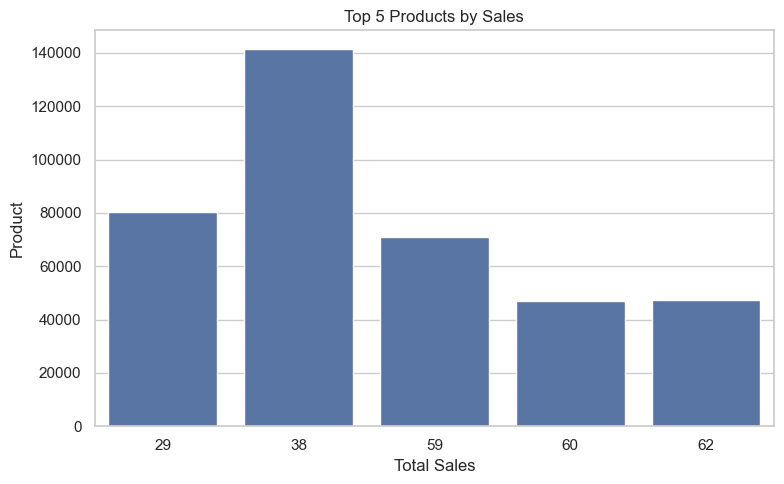


Country with Highest Orders: USA


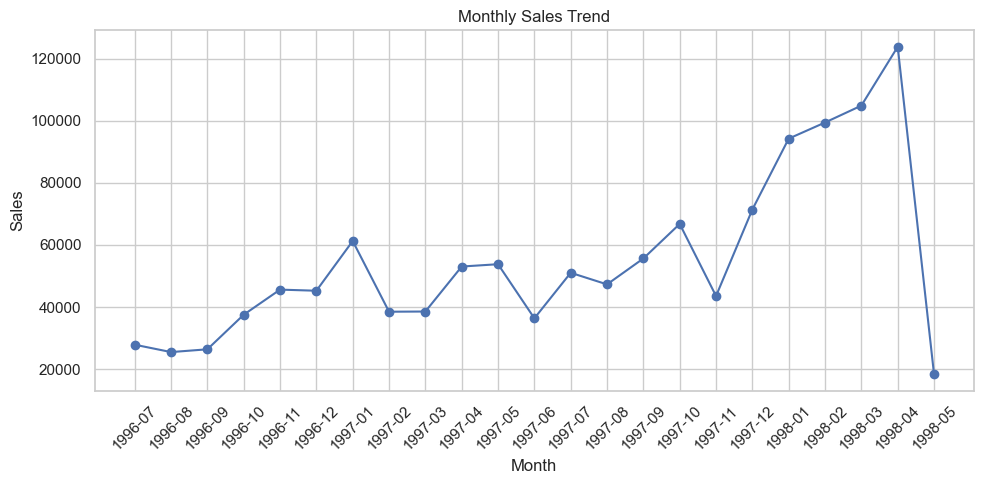


Salesperson Performance:
 employee_id
4    232890.8460
3    202812.8430
1    192107.6045
2    166537.7550
8    126862.2775
7    124568.2350
9     77308.0665
6     73913.1295
5     68792.2825
Name: Sales, dtype: float64


In [40]:
# =========================
# LOAD DATA
# =========================
orders = pd.read_csv('northwind_orders.csv')
data = pd.read_csv('northwind.csv') 
df = data.merge(
    orders,
    on="order_id",
    how="left",
    suffixes=("", "_order")
)

# Convert date
df['order_date'] = pd.to_datetime(df['order_date'])

# =========================
# JOIN TABLES
# =========================
df['Sales'] = df['unit_price'] * df['quantity'] * (1 - df.get('discount', 0))

# =========================
# 1. TOP 5 PRODUCTS BY TOTAL SALES
# =========================
top_products = df.groupby('product_id')['Sales'].sum().sort_values(ascending=False).head(5)

print("\nTop 5 Products by Sales:\n", top_products)

# Bar Chart
plt.figure(figsize=(8,5))
sns.barplot(x=top_products.index, y=top_products.values)
plt.title("Top 5 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

# =========================
# 2. COUNTRY WITH HIGHEST NUMBER OF ORDERS
# =========================
country_orders = df['ship_country'].value_counts()
top_country = country_orders.idxmax()
print("\nCountry with Highest Orders:", top_country)

# =========================
# 3. MONTHLY SALES TREND
# =========================
df['Month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

# Convert Period to string for plotting
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

# =========================
# 5. SALESPERSON PERFORMANCE
# =========================
salesperson_perf = df.groupby('employee_id')['Sales'].sum().sort_values(ascending=False)

print("\nSalesperson Performance:\n", salesperson_perf)

In [39]:
df

,order_id,product_id,unit_price,quantity,discount,customer_id,employee_id,order_date,required_date,shipped_date,ship_via,freight,ship_name,ship_address,ship_city,ship_region,ship_postal_code,ship_country,Sales,Month
0,10248,11,14.00,12,0.00,VINET,5,1996-07-04,8/1/1996,7/16/1996,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France,168.000,1996-07
1,10248,42,9.80,10,0.00,VINET,5,1996-07-04,8/1/1996,7/16/1996,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France,98.000,1996-07
2,10248,72,34.80,5,0.00,VINET,5,1996-07-04,8/1/1996,7/16/1996,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,NaN,51100,France,174.000,1996-07
3,10249,14,18.60,9,0.00,TOMSP,6,1996-07-05,8/16/1996,7/10/1996,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,NaN,44087,Germany,167.400,1996-07
4,10249,51,42.40,40,0.00,TOMSP,6,1996-07-05,8/16/1996,7/10/1996,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,NaN,44087,Germany,1696.000,1996-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150,11077,64,33.25,2,0.03,RATTC,1,1998-05-06,6/3/1998,NaN,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,Albuquerque,NM,87110,USA,64.505,1998-05
2151,11077,66,17.00,1,0.00,RATTC,1,1998-05-06,6/3/1998,NaN,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,Albuquerque,NM,87110,USA,17.000,1998-05
2152,11077,73,15.00,2,0.01,RATTC,1,1998-05-06,6/3/1998,NaN,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,Albuquerque,NM,87110,USA,29.700,1998-05
2153,11077,75,7.75,4,0.00,RATTC,1,1998-05-06,6/3/1998,NaN,2,8.53,Rattlesnake Canyon Grocery,2817 Milton Dr.,Albuquerque,NM,87110,USA,31.000,1998-05
